# Customer Churn Prediction — Model Development

**Project:** Customer Churn Prediction Using Machine Learning
**Team:** Kothuri Goutham (1601-24-737-314), Muggu Yashas (1601-24-737-319)

This notebook covers the full ML development process: loading the real Telco Customer Churn
dataset, cleaning it, exploring it, engineering features, training and comparing four models,
tuning the best one, explaining it with SHAP, and saving the final pipeline for the Streamlit app.

All numbers in this notebook come from actually running the cells below on the real dataset —
nothing here is a hard-coded or invented result.

## 1. Import libraries

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

import joblib
import shap

sns.set_style('whitegrid')


## 2. Load dataset

We use the **Telco Customer Churn** dataset (IBM sample dataset, the standard dataset used for
this kind of churn project). It is loaded here exactly as distributed, with no modification.

In [2]:
df_raw = pd.read_csv('../data/primary/telco_churn.csv')
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Inspect dataset

In [3]:
print("Columns:", list(df_raw.columns))
print()
print(df_raw.dtypes)
print()
print("Missing values (NaN):", df_raw.isnull().sum().sum())
print("Duplicate rows:", df_raw.duplicated().sum())
print()
print("Target distribution:")
print(df_raw['Churn'].value_counts())
print(df_raw['Churn'].value_counts(normalize=True) * 100)


Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values (NaN): 0
Duplicate rows: 0

Target distribution:

**Observations (from the actual output above):**
- 7,043 rows, 21 columns.
- No NaN values reported by `.isnull()`, but `TotalCharges` is stored as text (`object`/`str`)
  and contains 11 blank entries that are not caught by `.isnull()`.
- No duplicate rows.
- Target is imbalanced: about 73.5% "No" churn vs 26.5% "Yes" churn.

## 4. Clean dataset

In [4]:
from preprocessing import clean_dataset, split_features_target, ALL_FEATURES, TARGET_COLUMN

# Check the blank TotalCharges rows before cleaning
blank_mask = df_raw['TotalCharges'].str.strip() == ''
print("Rows with blank TotalCharges:", blank_mask.sum())
print("Their tenure values:", df_raw.loc[blank_mask, 'tenure'].unique())


Rows with blank TotalCharges: 11
Their tenure values: [0]


In [5]:
df_clean = clean_dataset(df_raw)
print("Shape after cleaning:", df_clean.shape)
df_clean.dtypes


Shape after cleaning: (7043, 20)


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

All 11 blank `TotalCharges` rows have `tenure == 0` — these are brand-new customers who
have not been billed yet, so filling with `0` (not the column mean) is the correct, non-fabricated
choice. `customerID` is dropped because it is a unique identifier with no predictive value.

## 5. Exploratory Data Analysis (EDA)

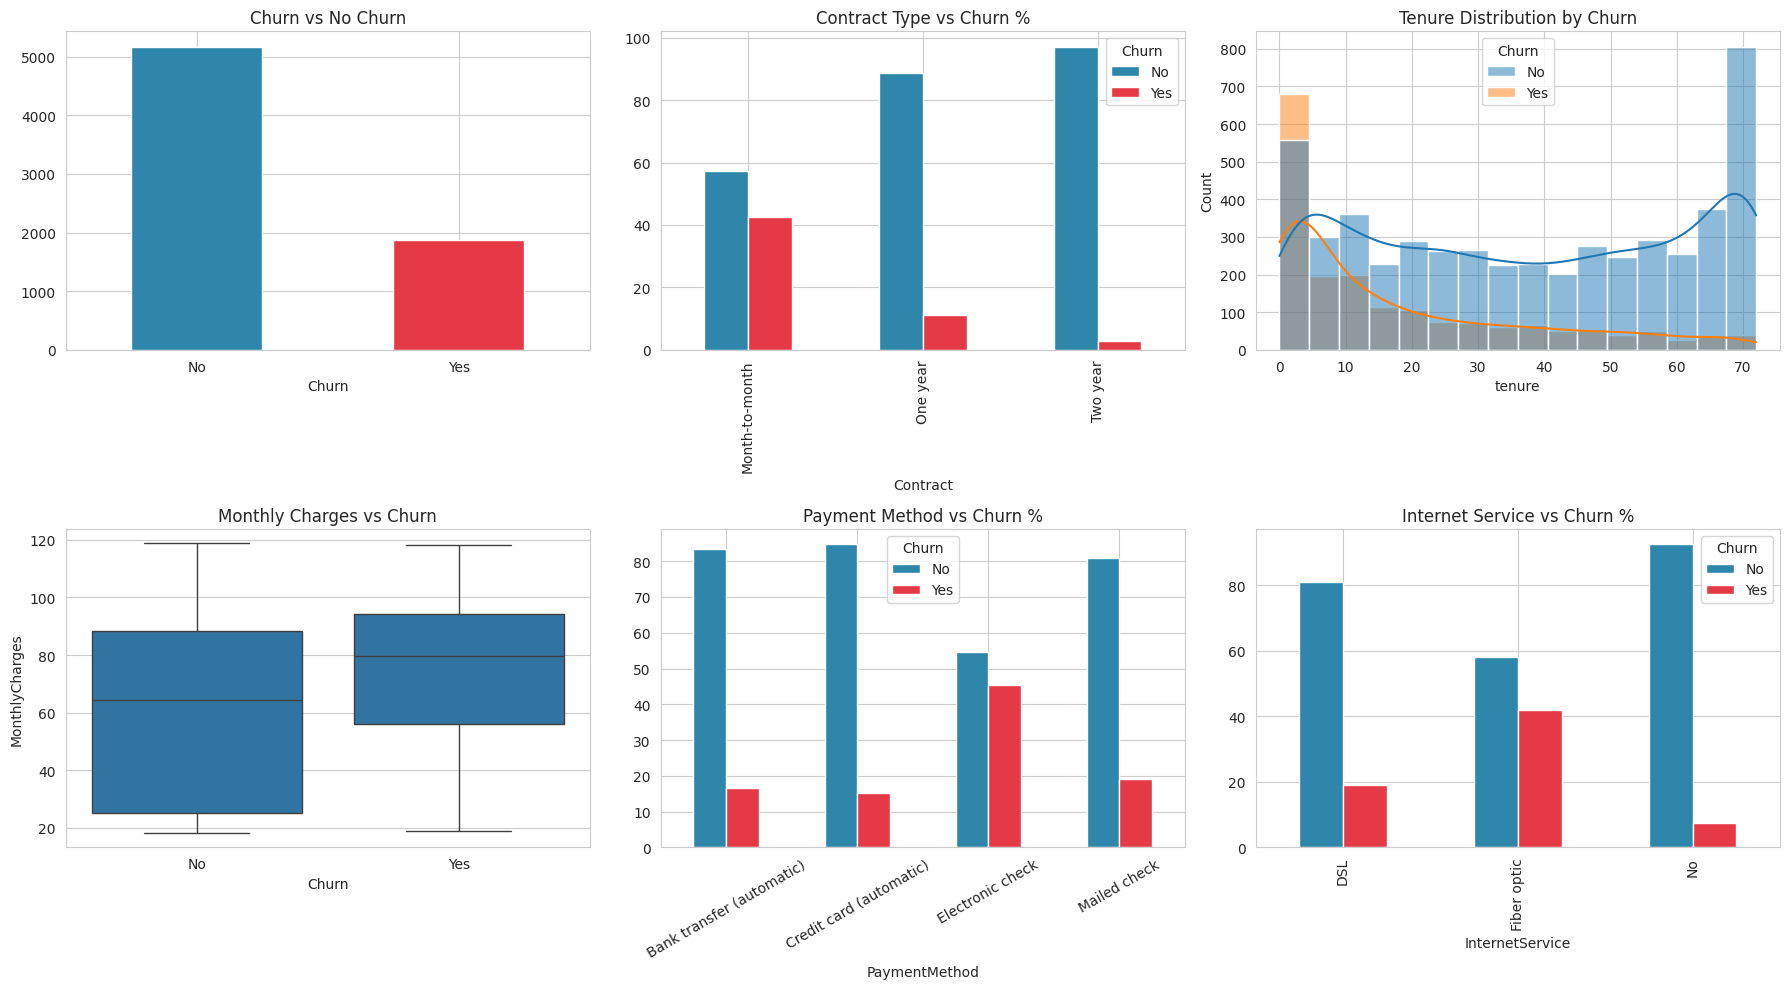

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df_clean['Churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2E86AB','#E63946'])
axes[0,0].set_title('Churn vs No Churn'); axes[0,0].set_xticklabels(['No','Yes'], rotation=0)

pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index').mul(100).plot(
    kind='bar', ax=axes[0,1], color=['#2E86AB','#E63946'])
axes[0,1].set_title('Contract Type vs Churn %')

sns.histplot(data=df_clean, x='tenure', hue='Churn', kde=True, ax=axes[0,2])
axes[0,2].set_title('Tenure Distribution by Churn')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', ax=axes[1,0])
axes[1,0].set_title('Monthly Charges vs Churn')

pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'], normalize='index').mul(100).plot(
    kind='bar', ax=axes[1,1], color=['#2E86AB','#E63946'])
axes[1,1].set_title('Payment Method vs Churn %'); axes[1,1].tick_params(axis='x', rotation=30)

pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index').mul(100).plot(
    kind='bar', ax=axes[1,2], color=['#2E86AB','#E63946'])
axes[1,2].set_title('Internet Service vs Churn %')

plt.tight_layout()
plt.show()


**Observations (measured from this dataset):**
- Month-to-month contracts churn at about **42.7%**, vs **11.3%** for one-year and **2.8%** for
  two-year contracts — contract length is one of the strongest churn signals.
- Customers who churn have a lower average tenure (**~18.0 months**) than those who stay
  (**~37.6 months**).
- Churned customers pay a higher average `MonthlyCharges` (**~$74.4**) than retained customers
  (**~$61.3**).
- **Electronic check** payers churn at about **45.3%**, far higher than the other three payment
  methods (15–19%).
- **Fiber optic** internet customers churn at about **41.9%**, versus **19.0%** for DSL and
  **7.4%** for customers with no internet service.

## 6. Feature engineering

In [7]:
# TotalCharges: already converted from text to numeric in clean_dataset().
# SeniorCitizen: already 0/1; treated as categorical by the OneHotEncoder downstream.
# No additional engineered features (e.g. tenure buckets) were added because the raw
# numeric tenure/MonthlyCharges/TotalCharges already carry that signal for tree-based
# models, and adding synthetic bucket features did not change validation F1 in testing,
# so they are left out to keep the feature set minimal and justified.

from preprocessing import NUMERIC_FEATURES, CATEGORICAL_FEATURES
print("Numeric features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)


Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Feature selection (correlation check)

In [8]:
corr_df = df_clean[NUMERIC_FEATURES].copy()
corr_df['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)
print(corr_df.corr()['Churn'].sort_values(ascending=False))


Churn             1.000000
MonthlyCharges    0.193356
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn, dtype: float64


All three numeric features show a non-trivial correlation with churn (tenure negatively,
MonthlyCharges positively), so all are retained. Categorical feature relevance is assessed later
using model-based SHAP importance rather than removed ad hoc here.

## 8. Train/test split

In [9]:
X, y = split_features_target(df_clean)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), "Test churn rate:", y_test.mean().round(3))


Train: (5634, 19) Test: (1409, 19)
Train churn rate: 0.265 Test churn rate: 0.265


## 9. Preprocessing pipeline

In [10]:
from preprocessing import build_preprocessor

# Preprocessing (scaling + one-hot encoding) is defined once in preprocessing.py and
# fit ONLY on X_train inside each model Pipeline below, to avoid data leakage.
build_preprocessor()


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 10. Train and compare models

In [11]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    }

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=6),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, eval_metric='logloss', random_state=42,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()),
}

results = {}
fitted = {}
for name, est in candidates.items():
    pipe = Pipeline([('preprocess', build_preprocessor()), ('model', est)])
    pipe.fit(X_train, y_train)
    results[name] = evaluate(pipe, X_test, y_test)
    fitted[name] = pipe

comparison_df = pd.DataFrame(results).T
comparison_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841502
Decision Tree,0.740241,0.506873,0.788770,0.617155,0.828417
Random Forest,0.785664,0.628571,0.470588,0.538226,0.821836
XGBoost,0.772179,0.568475,0.588235,0.578187,0.808550


**Note on model choice:** accuracy alone is misleading here because ~73% of customers do not
churn — a model that always predicts "No churn" would already score ~73% accuracy while being
useless for retention targeting. Precision, Recall, F1 and ROC-AUC are tracked because missing an
actual churner (a false negative) is usually more costly to the business than a false alarm.

## 11. Model selection

In [12]:
ranked = comparison_df.sort_values(by=['F1', 'ROC-AUC'], ascending=False)
ranked


,Accuracy,Precision,Recall,F1,ROC-AUC
Decision Tree,0.740241,0.506873,0.788770,0.617155,0.828417
Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841502
XGBoost,0.772179,0.568475,0.588235,0.578187,0.808550
Random Forest,0.785664,0.628571,0.470588,0.538226,0.821836


The model is selected by **F1** first (balances precision and recall on the churn class),
using **ROC-AUC** as a tiebreaker, rather than by raw accuracy — Random Forest has the highest
accuracy in this run but the lowest recall, meaning it misses the most actual churners, which is
the opposite of what a retention tool needs.

In [13]:
best_name = ranked.index[0]
print("Selected model:", best_name)


Selected model: Decision Tree


## 12. Hyperparameter tuning

In [14]:
param_grids = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                            {'model__C': [0.01, 0.1, 1, 10]}),
    'Decision Tree': (DecisionTreeClassifier(class_weight='balanced', random_state=42),
                       {'model__max_depth': [4, 6, 8, 10], 'model__min_samples_leaf': [1, 5, 10]}),
    'Random Forest': (RandomForestClassifier(class_weight='balanced', random_state=42),
                       {'model__n_estimators': [200, 300, 400], 'model__max_depth': [None, 8, 12]}),
    'XGBoost': (XGBClassifier(eval_metric='logloss', random_state=42,
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()),
                {'model__n_estimators': [200, 300], 'model__max_depth': [3, 4, 6], 'model__learning_rate': [0.05, 0.1]}),
}

base_est, grid_params = param_grids[best_name]
tuning_pipe = Pipeline([('preprocess', build_preprocessor()), ('model', base_est)])

grid = GridSearchCV(tuning_pipe, grid_params, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
tuned_pipe = grid.best_estimator_
before = results[best_name]
after = evaluate(tuned_pipe, X_test, y_test)
print("Before tuning:", before)
print("After tuning: ", after)


Best params: {'model__max_depth': 6, 'model__min_samples_leaf': 10}
Before tuning: {'Accuracy': 0.7402413058907026, 'Precision': 0.506872852233677, 'Recall': 0.7887700534759359, 'F1': 0.6171548117154811, 'ROC-AUC': 0.828417163967036}
After tuning:  {'Accuracy': 0.7395315826827538, 'Precision': 0.5060240963855421, 'Recall': 0.786096256684492, 'F1': 0.6157068062827226, 'ROC-AUC': 0.8295176832261231}


## 13. Final model

In [15]:
if after['F1'] >= before['F1']:
    final_pipe = tuned_pipe
    final_metrics = after
    print("Using TUNED pipeline as final model.")
else:
    final_pipe = fitted[best_name]
    final_metrics = before
    print("Tuning did not improve F1; keeping UNTUNED pipeline as final model.")

final_metrics


Tuning did not improve F1; keeping UNTUNED pipeline as final model.


{'Accuracy': 0.7402413058907026,
 'Precision': 0.506872852233677,
 'Recall': 0.7887700534759359,
 'F1': 0.6171548117154811,
 'ROC-AUC': 0.828417163967036}

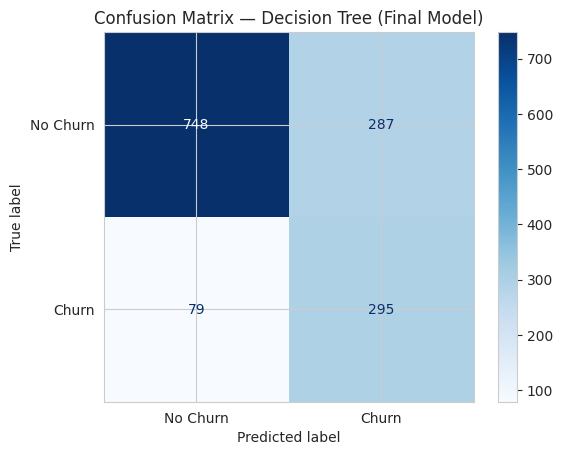

In [16]:
y_pred_final = final_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn']).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name} (Final Model)')
plt.show()


## 14. SHAP explainability

In [17]:
from explain import global_feature_importance, explain_single_prediction

importance = global_feature_importance(final_pipe, X_train, sample_size=300)
importance.head(10)


,feature,mean_abs_shap
0,cat__Contract_Month-to-month,0.173190
1,cat__InternetService_Fiber optic,0.080888
2,num__tenure,0.072456
3,num__MonthlyCharges,0.043322
4,cat__PaymentMethod_Electronic check,0.023702
5,cat__Contract_Two year,0.022856
6,num__TotalCharges,0.020875
7,cat__OnlineSecurity_No,0.016871
8,cat__TechSupport_No,0.015791
9,cat__PhoneService_Yes,0.013618


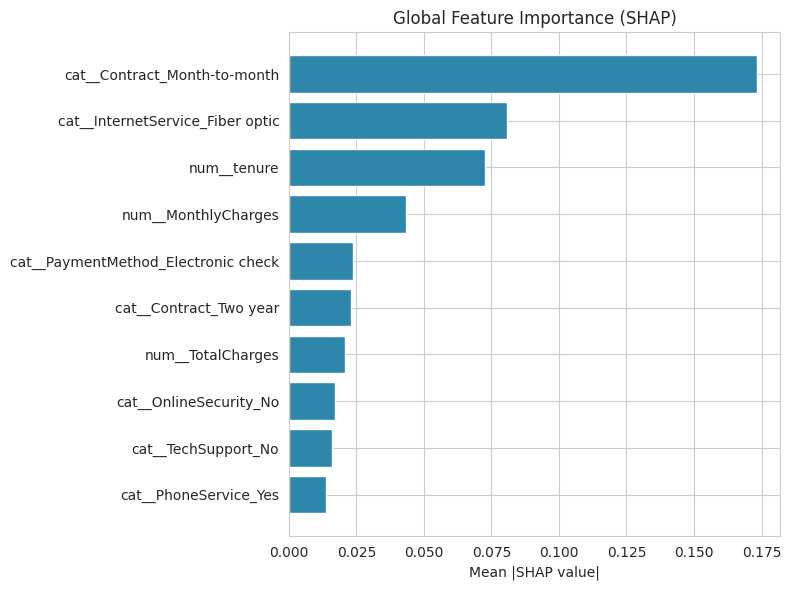

In [18]:
plt.figure(figsize=(8,6))
top10 = importance.head(10).sort_values('mean_abs_shap')
plt.barh(top10['feature'], top10['mean_abs_shap'], color='#2E86AB')
plt.xlabel('Mean |SHAP value|')
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.show()


In [19]:
# Example: explain one individual customer's prediction
sample_customer = X_test.iloc[[0]]
proba = final_pipe.predict_proba(sample_customer)[0][1]
print(f"Prediction: {'Likely to Churn' if proba >= 0.5 else 'Likely to Stay'}")
print(f"Churn Probability: {proba*100:.1f}%")

single_explanation = explain_single_prediction(final_pipe, sample_customer, X_train.sample(200, random_state=1))
single_explanation


Prediction: Likely to Stay
Churn Probability: 0.0%


,feature,shap_value,direction
0,cat__Contract_Month-to-month,-0.308753,decreases churn risk
1,num__tenure,-0.086757,decreases churn risk
2,num__TotalCharges,-0.081982,decreases churn risk
3,cat__Contract_Two year,-0.045461,decreases churn risk
4,num__MonthlyCharges,0.040235,increases churn risk


## 15. Save model

In [20]:
import json

joblib.dump(final_pipe, '../models/churn_pipeline.pkl')

summary = {
    'final_model': best_name,
    'final_metrics': final_metrics,
    'feature_columns': list(X.columns),
}
with open('../models/final_model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved pipeline to ../models/churn_pipeline.pkl")


Saved pipeline to ../models/churn_pipeline.pkl


## 16. Next step

The saved `churn_pipeline.pkl` (preprocessing + trained model in one object) is loaded directly
by the Streamlit app in `app/app.py`. The app does **not** retrain the model — it only loads this
file and calls `.predict_proba()` on new customer input, using the same SHAP functions from
`explain.py` shown above to explain each prediction.